# 02 - Central Tendency, Dispersion, and Visualization


## 1) Learning Objectives

- Compute mean, median, and mode clearly.
- Compare variance, standard deviation, and range.
- Explain when median is better than mean.
- Use basic plots to support interpretation.

## 2) Why This Topic Matters

Statistics starts with understanding your data. If we skip inspection or mix up variable types, later analysis can become misleading.

## 3) Short and Simple Theory Explanation

- **Mean**: average; sensitive to outliers.
- **Median**: middle value; more robust to outliers.
- **Mode**: most frequent value.
- **Variance** (`var()`): average squared distance from mean.
- **Standard deviation** (`std()`): square root of variance, in original units.
- **Range**: maximum minus minimum.

## 4) Step-by-Step Code Examples

### Step 4.1 — Setup and create synthetic data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style='whitegrid')

rng = np.random.default_rng(42)
number_of_rows = 100

normal_scores = rng.normal(loc=70, scale=8, size=number_of_rows)
scores_with_outlier = normal_scores.copy()
scores_with_outlier[0] = 150  # one extreme outlier

course_data = pd.DataFrame({
    'normal_score': np.round(normal_scores, 1),
    'score_with_outlier': np.round(scores_with_outlier, 1),
    'study_group': rng.choice(['Group A', 'Group B'], size=number_of_rows),
})

course_data.head()

,normal_score,score_with_outlier,study_group
0,72.4,150.0,Group A
1,61.7,61.7,Group A
2,76.0,76.0,Group B
3,77.5,77.5,Group B
4,54.4,54.4,Group A


### Step 4.2 — Mean, median, and mode

In [2]:
column_name = 'normal_score'

mean_value = course_data[column_name].mean()
median_value = course_data[column_name].median()
mode_series = course_data[column_name].mode()

print('Mean:', round(mean_value, 2))
print('Median:', round(median_value, 2))
print('Mode (first mode if several):', mode_series.iloc[0])

Mean: 69.59
Median: 70.0
Mode (first mode if several): 66.6


**Interpretation:** For the normal-looking variable, mean and median are close. That often happens when data are symmetric.

### Step 4.3 — Effect of one outlier on mean vs median

In [3]:
for col in ['normal_score', 'score_with_outlier']:
    print('\nColumn:', col)
    print('  Mean  :', round(course_data[col].mean(), 2))
    print('  Median:', round(course_data[col].median(), 2))


Column: normal_score
  Mean  : 69.59
  Median: 70.0

Column: score_with_outlier
  Mean  : 70.37
  Median: 70.0


**Interpretation:** After adding one very high value, the mean jumps up but the median changes much less. That is why median is often preferred when outliers exist.

### Step 4.4 — Dispersion: variance, standard deviation, range

In [4]:
col = 'normal_score'
variance_value = course_data[col].var()
std_value = course_data[col].std()
range_value = course_data[col].max() - course_data[col].min()

summary = pd.DataFrame({
    'variance': [variance_value],
    'std': [std_value],
    'range': [range_value],
}).round(2)
summary

,variance,std,range
0,38.59,6.21,32.7


**Interpretation:** Standard deviation is easier to interpret than variance because it uses the same units as the data (points).

### Step 4.5 — Group comparison

In [5]:
group_summary = course_data.groupby('study_group')['normal_score'].agg(['mean', 'median', 'std']).round(2)
group_summary

,mean,median,std
study_group,,,
Group A,69.60,70.75,6.39
Group B,69.58,68.65,6.05


### Step 4.6 — Visualize with histogram, boxplot, and scatter plot

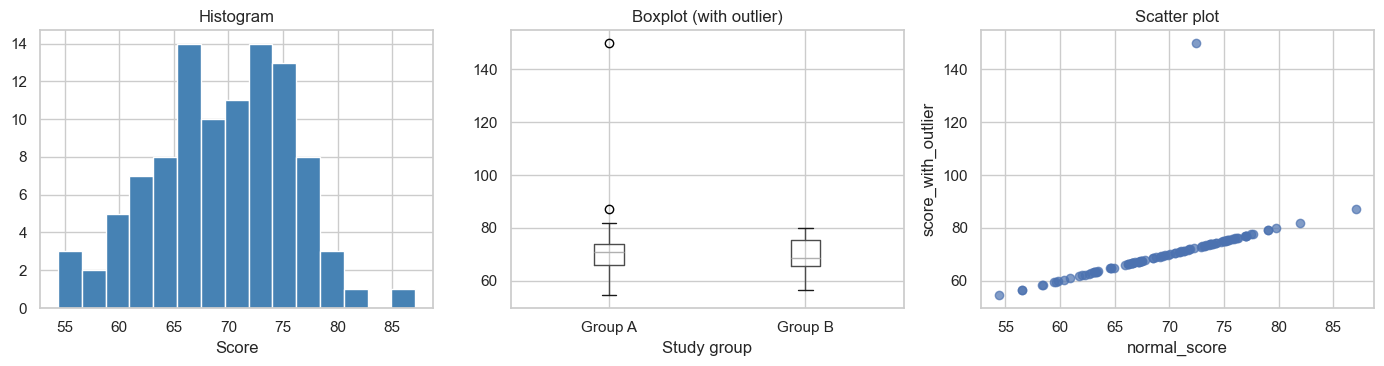

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(course_data['normal_score'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Score')

course_data.boxplot(column='score_with_outlier', by='study_group', ax=axes[1])
axes[1].set_title('Boxplot (with outlier)')
axes[1].set_xlabel('Study group')

axes[2].scatter(course_data['normal_score'], course_data['score_with_outlier'], alpha=0.7)
axes[2].set_title('Scatter plot')
axes[2].set_xlabel('normal_score')
axes[2].set_ylabel('score_with_outlier')

plt.suptitle('')
plt.tight_layout()
plt.show()

**Interpretation:**
- The **histogram** shows how values are spread.
- The **boxplot** highlights the outlier as a point far from the box.
- The **scatter plot** shows relationship between two numeric columns.

### Step 4.7 — Add or remove an outlier and observe changes

In [7]:
without_outlier = course_data['score_with_outlier'].copy()
without_outlier.iloc[0] = 72  # replace extreme value with a typical score

comparison = pd.DataFrame({
    'with_outlier_mean': [course_data['score_with_outlier'].mean()],
    'with_outlier_median': [course_data['score_with_outlier'].median()],
    'without_outlier_mean': [without_outlier.mean()],
    'without_outlier_median': [without_outlier.median()],
}).round(2)
comparison

,with_outlier_mean,with_outlier_median,without_outlier_mean,without_outlier_median
0,70.37,70.0,69.59,70.0


**Interpretation:** Removing the outlier brings the mean closer to the median.

## 7) Summary Interpretation

We compared mean, median, and spread measures and saw how one outlier can distort the mean but not the median.

## 8) Student Check Questions

### Question 1 (Conceptual)
Why can the median be better than the mean when outliers exist?

**Suggested answer:**
Outliers pull the mean toward extreme values. The median depends on the middle order of values, so it is more stable.

### Question 2 (Small code change)
Add a new outlier (for example, score = 200) to `score_with_outlier` and observe how mean and median change.

Try the change in a new code cell below and write one sentence about what you observed.

In [8]:
# Your code change for Question 2 goes here.


## 9) Key Takeaways

- Report center and spread together.
- Use plots to support tables.
- Prefer median when extreme values are present.
- Always interpret numbers in context.

## 10) Optional Short Practice / Challenge

Create a third column with a strongly skewed distribution using `rng.exponential(scale=10, size=number_of_rows)` and compare mean vs median.

## 11) Code Refinement Tasks — Check Your Understanding

Complete **both** refinements below. This checks whether you understood the notebook, not only whether you can run it.

**Instructions:**
1. Read each task carefully.
2. Write or change Python code in the cells below.
3. **Run each cell** (and rerun earlier cells if needed).
4. Compare the new output with the original notebook results.
5. Write a short note: *What changed? Did it match your expectation?*

### Refinement 1
In **Step 4.3**, add a second extreme outlier: set two rows in `score_with_outlier` to `180` and `200`. Recompute mean and median and print both. Which measure changed more?

### Refinement 2
In **Step 4.6**, change the histogram bins from `15` to `5`, rerun the plot, and describe how the shape looks different. Does the data change, or only the visual detail?

In [9]:
# Refinement 1 — your code here
# After editing, run this cell and describe the result in one sentence.


In [10]:
# Refinement 2 — your code here
# After editing, run this cell and describe the result in one sentence.


**Reflection (write in your own words):**
- Refinement 1: What did you change, and what happened after rerun?
- Refinement 2: What did you change, and what happened after rerun?
- Do you understand *why* the output changed?

In [11]:
print('Notebook 02 completed successfully.')

Notebook 02 completed successfully.
